# Evaluating the model on the generated anomalies

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
# --- CONFIGURATION ---
DATA_PATH = 'data/final_models_input/train_dataset_with_anomalies.pkl' # Raw generated anomaly data
SCALER_PATH = 'data/final_models_input/uni_scaler.pkl'
MODEL_PATH = 'lstm_uni_autoencoder_model.pth'

# Model Config
SEQ_LEN = 300 
EMBEDDING_DIM = 128
N_FEATURES = 4
BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:

# --- MODEL CLASS (Must match training) ---
class Encoder(nn.Module):
    def __init__(self, n_features, embedding_dim):
        super(Encoder, self).__init__()
        # 1. Unidirectional LSTM (bidirectional=False)
        # We increase hidden_size to 128 to keep capacity high
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=256, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=embedding_dim, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
    def forward(self, x):
        x, (_, _) = self.lstm1(x)
        _, (hidden, _) = self.lstm2(x)
        return hidden[-1]

class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim, n_features):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        
        # Decoder matches Encoder
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=256, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
        self.output_layer = nn.Linear(256, n_features)

    def forward(self, x):
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.output_layer(x)
        return x
    
class RecurrentAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(RecurrentAutoencoder, self).__init__()
        self.encoder = Encoder(n_features, embedding_dim)
        self.decoder = Decoder(seq_len, embedding_dim, n_features)

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


### Top-K scoring

In [13]:
# --- TOP-K SCORING FUNCTION ---
def calculate_top_k_score(input_tensor, recon_tensor, k=30):
    """
    Calculates the Top-K Mean Reconstruction Error.
    
    Args:
        input_tensor: (Batch, Time, Features)
        recon_tensor: (Batch, Time, Features)
        k: Number of time steps to consider (e.g., 30)
        
    Returns:
        scores: (Batch,) - One score per sample
    """
    # 1. Calculate Absolute Error per point
    # Shape: (Batch, 300, 4)
    error = torch.abs(input_tensor - recon_tensor)
    
    # 2. Aggregation over Features
    # We SUM over features instead of Mean. 
    # Why? If only 1 sensor fails (Drift), Mean divides the error by 4. Sum keeps it high.
    # Shape: (Batch, 300)
    error_sum_features = torch.sum(error, dim=2)
    
    # 3. Find the Top K errors along the Time axis
    # This picks the 30 worst moments in the sequence
    # values shape: (Batch, K)
    top_k_values, _ = torch.topk(error_sum_features, k=k, dim=1)
    
    # 4. Average these Top K values
    # Shape: (Batch,)
    scores = torch.mean(top_k_values, dim=1)
    
    return scores

In [18]:

# --- EVALUATION LOGIC ---
def evaluate_synthetic_performance():
    # 1. Load Data
    print("Loading Data & Scaler...")
    with open(DATA_PATH, 'rb') as f:
        data = pickle.load(f)
        X_raw = data['X']
        y_labels = data['y'] # 0=Normal, 1=Leak, 2=Offset, 3=Drift
        
    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)

    # 2. Preprocess
    print("Preprocessing...")
    N, T, F = X_raw.shape
    X_flat = X_raw.reshape(-1, F)
    X_scaled = scaler.transform(X_flat).reshape(N, T, F)
    X_downsampled = X_scaled[:, ::5, :] # 1500 -> 300
    
    tensor_x = torch.FloatTensor(X_downsampled).to(device)
    loader = DataLoader(TensorDataset(tensor_x), batch_size=BATCH_SIZE, shuffle=False)

    # 3. Load Model
    print("Running Inference...")
    model = RecurrentAutoencoder(SEQ_LEN, N_FEATURES, EMBEDDING_DIM).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    # # 4. Calculate Scores
    # all_scores = []
    # with torch.no_grad():
    #     for batch in loader:
    #         x = batch[0]
    #         recon = model(x)
    #         loss = torch.mean(torch.abs(x - recon), dim=(1, 2)) # MAE per sample
    #         all_scores.extend(loss.cpu().numpy())
    
    # all_scores = np.array(all_scores)

    # Define K (10% of 300 is a good starting point)
    K_STEPS = 30 

    # 4. Calculate Scores (IMPROVED METRIC)
    all_scores = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0]
            recon = model(x)
            
            # # Absolute Error Map: (Batch, 300, 4)
            # error_map = torch.abs(x - recon)
            
            # # STRATEGY: MAX OVER TIME, SUM OVER FEATURES
            # # 1. Find the worst moment in time for each feature
            # max_error_per_feature = torch.max(error_map, dim=1)[0] # Shape: (Batch, 4)
            
            # # 2. Sum the errors of the 4 features
            # # We sum instead of mean, so 1 bad sensor doesn't get diluted
            # score = torch.sum(max_error_per_feature, dim=1)
            score = calculate_top_k_score(x, recon, k=K_STEPS)
            all_scores.extend(score.cpu().numpy())

    all_scores = np.array(all_scores)

    # 5. Determine Threshold (Using only Normal Data)
    # Strategy: Threshold = Mean + 3 StdDev of Normal Data
    normal_indices = np.where(y_labels == 0)[0]
    normal_scores = all_scores[normal_indices]
    
    threshold = np.mean(normal_scores) + 3 * np.std(normal_scores)
    # Alternatively: Use 99th percentile to be safer against outliers
    # threshold = np.percentile(normal_scores, 99)
    
    print(f"\n--- THRESHOLD SETTING ---")
    print(f"Normal Mean Score: {np.mean(normal_scores):.5f}")
    print(f"Normal Max Score:  {np.max(normal_scores):.5f}")
    print(f"Calculated Threshold: {threshold:.5f}")

    # 6. Updated Fault Mapping
    # Based on the order in 'generate_comprehensive_anomalies'
    fault_names = {
        0: "Normal", 
        1: "Seal Leakage", 
        2: "Delayed Closure", 
        3: "Sensor Offset", 
        4: "Sensor Drift",
        5: "Water Hammer",
        6: "Stick-Slip/Jerky",
        7: "PID Hunting",
        8: "Signal Dropout"
    }
    
    # Define Colors for plotting
    colors = {
        0: 'blue',      # Normal
        1: 'red',       # Leak
        2: 'purple',    # Delay
        3: 'orange',    # Offset
        4: 'green',     # Drift
        5: 'brown',     # Hammer
        6: 'magenta',   # Jerky
        7: 'black',      # PID Hunting
        8: 'cyan'       # Signal Dropout
    }

    # 7. Print Table
    print(f"\n{'Fault Type':<20} | {'Detected':<10} | {'Avg Score':<10}")
    print("-" * 50)
    
    unique_labels = np.sort(np.unique(y_labels))
    
    for lbl in unique_labels:
        idxs = np.where(y_labels == lbl)[0]
        sc = all_scores[idxs]
        
        # Detection Rate
        detected_count = np.sum(sc > threshold)
        rate = detected_count / len(sc) * 100
        
        name = fault_names.get(lbl, f"Type {lbl}")
        print(f"{name:<20} | {rate:>8.1f}% | {np.mean(sc):.5f}")

    # 8. Visualization (Histograms)
    plt.figure(figsize=(12, 6))
    
    # Plot Normal first to be at the back
    lbl = 0
    plt.hist(all_scores[y_labels == lbl], bins=50, alpha=0.3, 
             label=fault_names[lbl], color=colors[lbl], density=True)

    # Plot Anomalies
    for lbl in unique_labels:
        if lbl == 0: continue
        plt.hist(all_scores[y_labels == lbl], bins=50, alpha=0.5, 
                 label=fault_names.get(lbl, f"Type {lbl}"), 
                 color=colors.get(lbl, 'gray'), density=True)
    
    plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
    plt.title(f"Anomaly Score Distribution (Top-{K_STEPS} Metric)")
    plt.xlabel("Reconstruction Error Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Loading Data & Scaler...
Preprocessing...
Running Inference...


C:\Users\shrey\AppData\Local\Temp\ipykernel_11648\3605218188.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d


--- THRESHOLD SETTING ---
Normal Mean Score: 0.28879
Normal Max Score:  0.76561
Calculated Threshold: 0.60143

Fault Type           | Detected   | Avg Score 
--------------------------------------------------
Normal               |      0.8% | 0.28879
Seal Leakage         |      1.0% | 0.35611
Delayed Closure      |      0.4% | 0.32432
Sensor Offset        |    100.0% | 0.86106
Sensor Drift         |      2.2% | 0.37921
Water Hammer         |      0.8% | 0.41365
Stick-Slip/Jerky     |      0.8% | 0.28995
PID Hunting          |      0.8% | 0.28879
Signal Dropout       |      0.8% | 0.30240


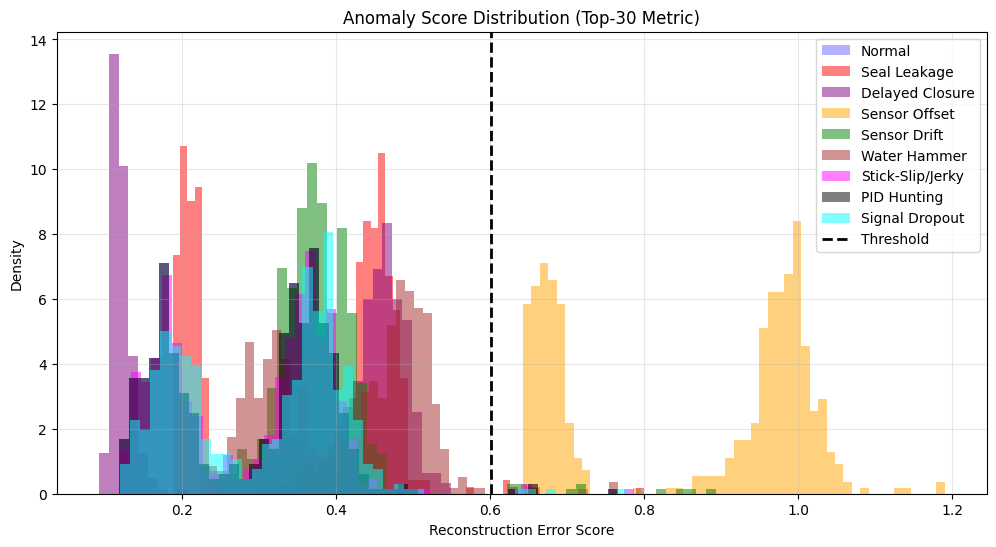

In [19]:
# Run Evaluation
evaluate_synthetic_performance()